In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lagp.utils.generate_data import load_data
import os
plt.style.use('ggplot')
import yaml
from ipywidgets import interact
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

In [164]:
with open("../configs/config_data_generation.yaml", "r") as f:
    configs = yaml.safe_load(f)

In [165]:
configs = configs["simulation"]

In [166]:
likelihood = "ald"
sample_size = 100
input_dim =1
replicate = 1
train_split = 0.75
file_path = f"../data/simulated_data/{sample_size}_{input_dim}/{likelihood}/data_replicate_{replicate}.npz"

In [167]:
f, X_train, y_train, X_test, y_test = load_data(likelihood = likelihood,
          sample_size = sample_size,
          input_dim = input_dim,
          replicate=replicate,
          train_split=train_split,
          file_path=file_path
        )

order_train_idx = np.argsort(X_train[:,0])
order_test_idx = np.argsort(X_test[:,0])

In [168]:
f = f[np.argsort(f)]
X_train = X_train[order_train_idx, 0]
y_train= y_train[order_train_idx]
X_test= X_test[order_test_idx,0]
y_test= y_test[order_test_idx]

Text(0.5, 1.0, 'Noise: ald. N: 100. Replicate: 1')

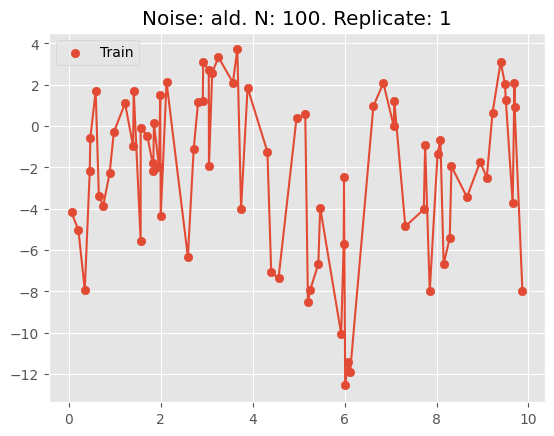

In [169]:
plt.scatter(X_train, y_train, label = "Train")
plt.plot(X_train, y_train)
plt.legend(labelcolor = "black")
plt.title(f"Noise: {likelihood}. N: {sample_size}. Replicate: {replicate}", color = "black")

In [170]:
def vis_train_data(likelihood, sample_size, replicate, input_dim):
    file_path = f"../data/simulated_data/{sample_size}_{input_dim}/{likelihood}/data_replicate_{replicate}.npz"

    f, X_train, y_train, X_test, y_test = load_data(likelihood = likelihood,
          sample_size = sample_size,
          input_dim = input_dim,
          replicate=replicate,
          train_split=train_split,
          file_path=file_path
        )

    fig = plt.figure(figsize=(15,6))
    
    if input_dim == 1:
      order_train_idx = np.argsort(X_train[:,0])
      order_test_idx = np.argsort(X_test[:,0])

      f = f[np.argsort(f)]
      X_train = X_train[order_train_idx, 0]
      y_train= y_train[order_train_idx]
      X_test= X_test[order_test_idx,0]
      y_test= y_test[order_test_idx]

      plt.scatter(X_train, y_train, label = "Train")
      plt.plot(X_train, y_train)
      plt.xlabel("X")
      plt.ylabel("Y")
      plt.legend(labelcolor = "black")
      plt.title(f"Noise: {likelihood}. N: {sample_size}. Replicate: {replicate}", color = "black")
      
          
    if input_dim ==2:
        # 1. Create a grid
      X = X_train[:,0]
      Y = X_train[:, 1]
      xi = np.linspace(min(X), max(X), 100)
      yi = np.linspace(min(Y), max(Y), 100)
      Xi, Yi = np.meshgrid(xi, yi)

      # 2. Interpolate Z values onto grid
      Zi = griddata((X, Y), y_train, (Xi, Yi), method='cubic')  # or 'linear', 'nearest'

      ax = fig.add_subplot(111, projection='3d')
      surf = ax.plot_surface(Xi, Yi, Zi, cmap='viridis')

      # 4. Add color bar and labels
      fig.colorbar(surf)
      ax.set_xlabel('X1')
      ax.set_ylabel('X2')
      ax.set_zlabel('Y')

    if input_dim > 2:
       print("cannot visualize if input dimension > 2")

    plt.show()

In [171]:
likelihoods = configs["likelihoods"]
sample_sizes = configs["sample_sizes"]
replicates = configs["replicates"]
input_dims = configs["dimensions"]

In [ ]:
interact(vis_train_data, likelihood = likelihoods, sample_size = sample_sizes
         , replicate = [i + 1 for i in range(replicates)], input_dim = input_dims)

interactive(children=(Dropdown(description='likelihood', options=('gaussian', 't', 'chi', 'ald'), value='gauss…

<function __main__.vis_train_data(likelihood, sample_size, replicate, input_dim)>